# Projet d'analyse numérique — Notebook principal

Ce notebook reprend la logique de `main.py`, mais dans un format interactif pour visualiser directement :
- les graphes,
- les résultats numériques,
- les comparaisons entre méthodes.


In [1]:

from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# =========================
# IMPORTS DE TON PROJET
# =========================
from src.interpolation.polynomial_interpolation import PolynomialInterpolation
from src.integration.newton_cotes import NewtonCotes
from src.integration.adaptive import AdaptiveIntegration

try:
    from src.integration.gauss import GaussQuadrature
except ImportError:
    GaussQuadrature = None

from src.applications.cooling_problem import CoolingProblem
from src.applications.FlowProblem import FlowProblem
from src.visualization.visualizer import Visualizer


In [2]:

# =========================
# DOSSIERS DE SORTIE
# =========================
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = RESULTS_DIR / "data"


def ensure_directories() -> None:
    """Crée les dossiers de sortie s'ils n'existent pas."""
    RESULTS_DIR.mkdir(exist_ok=True)
    FIGURES_DIR.mkdir(exist_ok=True)
    DATA_DIR.mkdir(exist_ok=True)


ensure_directories()
print("Dossiers prêts :", RESULTS_DIR, FIGURES_DIR, DATA_DIR)


Dossiers prêts : results results\figures results\data


In [3]:

# =========================
# DONNÉES EXPÉRIMENTALES
# =========================
def load_experimental_data() -> dict:
    """Charge les données expérimentales du sujet."""
    cooling_data = {
        "t": np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float),
        "T": np.array([90, 85, 72, 63, 58, 52, 48, 45, 43, 41, 40], dtype=float),
        "T_ambient": 20.0,
        "h_coeff": 50.0,
    }

    flow_data = {
        "x": np.array([0, 0.5, 1.2, 1.8, 2.5, 3.1, 3.7, 4.2, 4.8, 5.3, 6.0], dtype=float),
        "v": np.array([0, 2.1, 3.8, 5.2, 6.4, 7.0, 7.3, 7.2, 6.8, 5.9, 4.5], dtype=float),
    }

    return {"cooling": cooling_data, "flow": flow_data}


def save_json(data: dict, filepath: Path) -> None:
    """Sauvegarde un dictionnaire en JSON."""
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


def save_current_figure(filename: str) -> None:
    """Sauvegarde la figure matplotlib courante sans la fermer immédiatement."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")


def runge_function(x):
    """Fonction classique de Runge."""
    return 1.0 / (1.0 + 25.0 * x**2)


def chebyshev_nodes(a: float, b: float, n: int) -> np.ndarray:
    """Génère n points de Tchebychev sur [a, b]."""
    k = np.arange(1, n + 1)
    x_cheb = np.cos((2 * k - 1) * np.pi / (2 * n))
    return (a + b) / 2 + (b - a) / 2 * x_cheb


def test_function(x):
    """Fonction test pour la convergence."""
    return np.exp(x)


def exact_integral_exp_0_1():
    """Valeur exacte de ∫_0^1 e^x dx."""
    return np.e - 1.0


## 1. Chargement des données

In [4]:

data = load_experimental_data()

display(Markdown("### Données de refroidissement"))
print(data["cooling"])

display(Markdown("### Données d'écoulement"))
print(data["flow"])


### Données de refroidissement

{'t': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]), 'T': array([90., 85., 72., 63., 58., 52., 48., 45., 43., 41., 40.]), 'T_ambient': 20.0, 'h_coeff': 50.0}


### Données d'écoulement

{'x': array([0. , 0.5, 1.2, 1.8, 2.5, 3.1, 3.7, 4.2, 4.8, 5.3, 6. ]), 'v': array([0. , 2.1, 3.8, 5.2, 6.4, 7. , 7.3, 7.2, 6.8, 5.9, 4.5])}


## 2. Étude du phénomène de Runge


Degré n = 5
Erreur max (points équidistants) : 4.326690e-01
Erreur max (points de Tchebychev) : 5.558874e-01


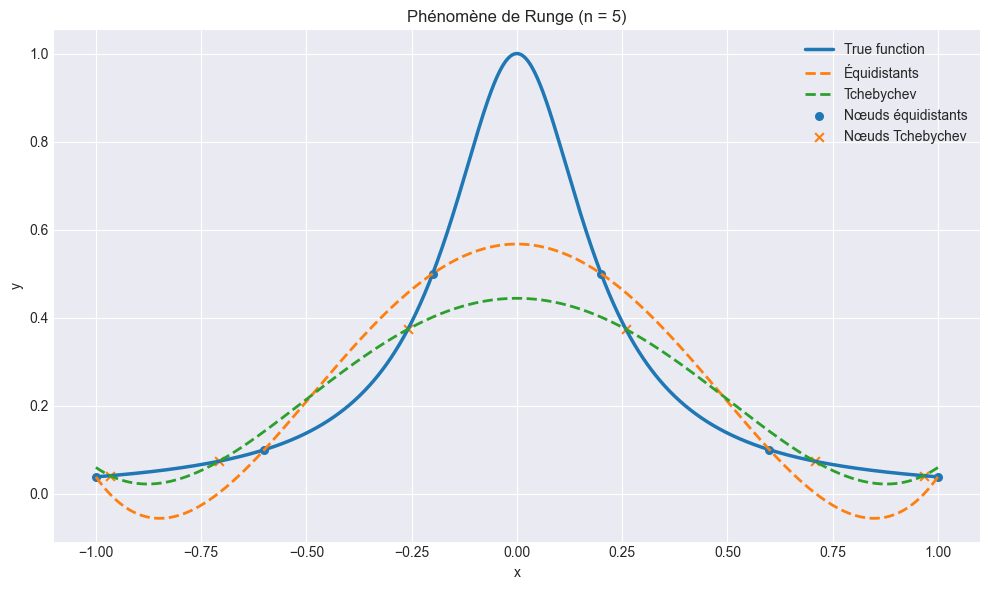


Degré n = 10
Erreur max (points équidistants) : 1.915633e+00
Erreur max (points de Tchebychev) : 1.091535e-01


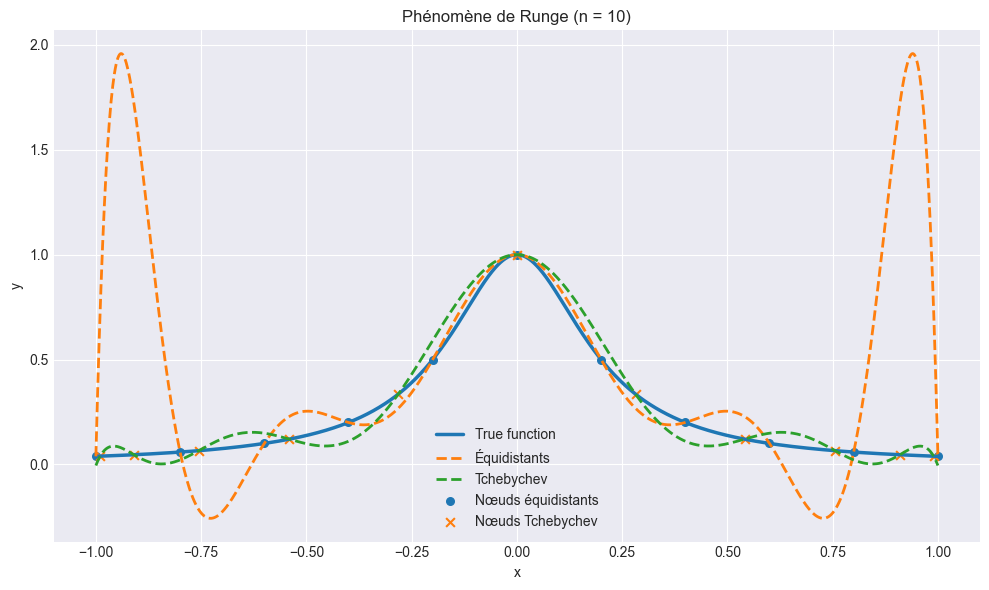


Degré n = 15
Erreur max (points équidistants) : 2.106860e+00
Erreur max (points de Tchebychev) : 8.309431e-02


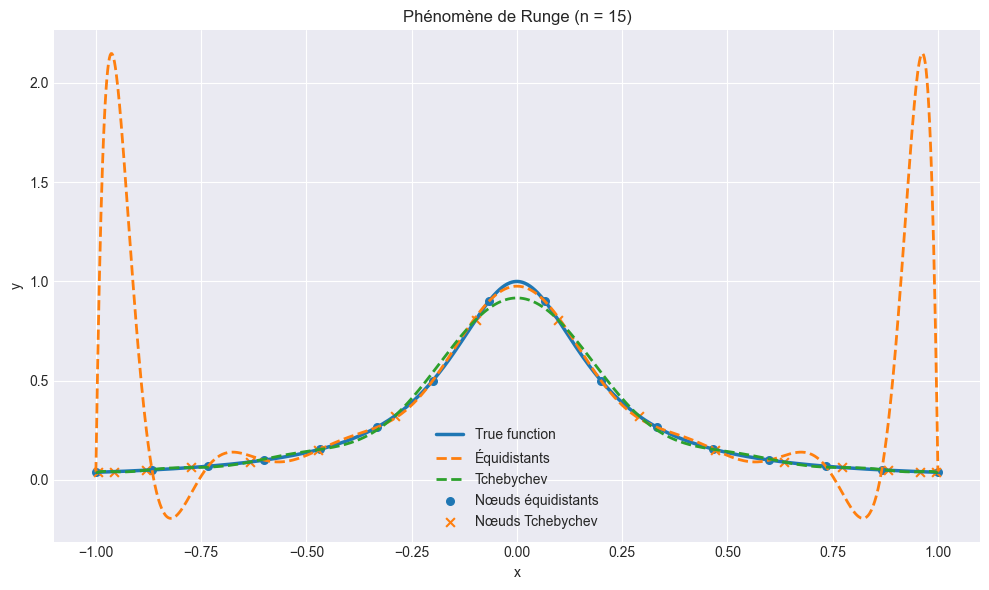


Degré n = 20
Erreur max (points équidistants) : 5.976840e+01
Erreur max (points de Tchebychev) : 1.533338e-02


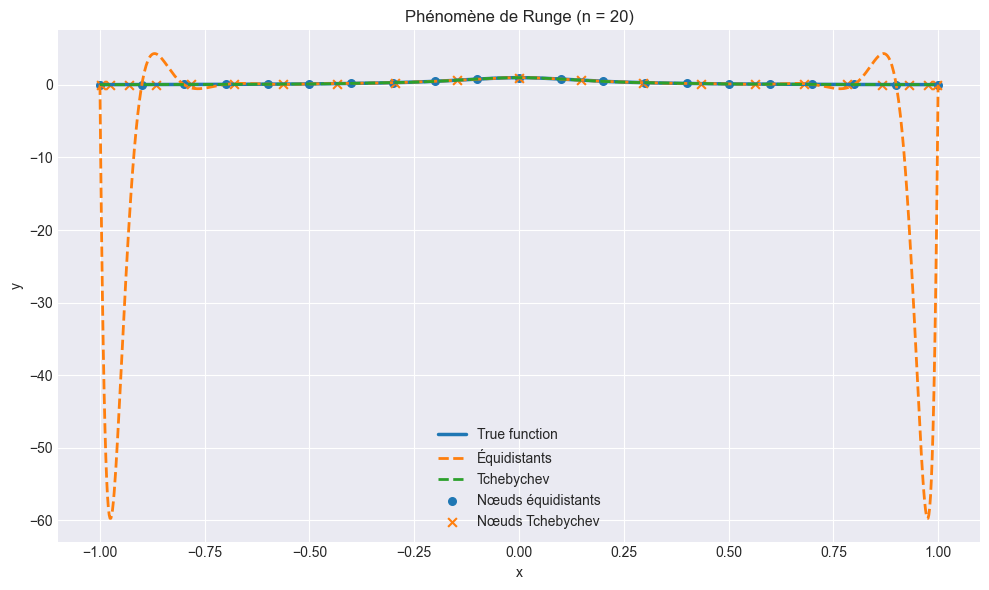

{'n_5': {'max_error_equidistant': 0.4326689924794599,
  'max_error_chebyshev': 0.555887387371419},
 'n_10': {'max_error_equidistant': 1.915633147501289,
  'max_error_chebyshev': 0.10915351076845337},
 'n_15': {'max_error_equidistant': 2.1068604877790977,
  'max_error_chebyshev': 0.08309430748091262},
 'n_20': {'max_error_equidistant': 59.76839905928312,
  'max_error_chebyshev': 0.01533338400337414}}

In [5]:

def study_runge_notebook() -> dict:
    """Étudie le phénomène de Runge et affiche les graphes dans le notebook."""
    a, b = -1.0, 1.0
    x_fine = np.linspace(a, b, 1000)
    y_true = runge_function(x_fine)

    degrees = [5, 10, 15, 20]
    results = {}
    visualizer = Visualizer(style="seaborn-v0_8-darkgrid", figsize=(10, 6))

    for n in degrees:
        x_equi = np.linspace(a, b, n + 1)
        y_equi = runge_function(x_equi)

        x_cheb = chebyshev_nodes(a, b, n + 1)
        y_cheb = runge_function(x_cheb)

        interp_equi = PolynomialInterpolation(x_equi, y_equi)
        interp_cheb = PolynomialInterpolation(x_cheb, y_cheb)

        y_equi_interp = interp_equi.evaluate(x_fine, method="newton")
        y_cheb_interp = interp_cheb.evaluate(x_fine, method="newton")

        err_equi = float(np.max(np.abs(y_true - y_equi_interp)))
        err_cheb = float(np.max(np.abs(y_true - y_cheb_interp)))

        results[f"n_{n}"] = {
            "max_error_equidistant": err_equi,
            "max_error_chebyshev": err_cheb,
        }

        print(f"\nDegré n = {n}")
        print(f"Erreur max (points équidistants) : {err_equi:.6e}")
        print(f"Erreur max (points de Tchebychev) : {err_cheb:.6e}")

        interpolations = {
            "Équidistants": y_equi_interp,
            "Tchebychev": y_cheb_interp,
        }

        visualizer.plot_runge_phenomenon(x_fine, y_true, interpolations)
        plt.scatter(x_equi, y_equi, label="Nœuds équidistants", marker="o", s=30)
        plt.scatter(x_cheb, y_cheb, label="Nœuds Tchebychev", marker="x", s=40)
        plt.title(f"Phénomène de Runge (n = {n})")
        plt.legend()
        plt.show()
        save_current_figure(f"runge_n_{n}.png")
        plt.close()

    return results


runge_results = study_runge_notebook()
runge_results


## 3. Analyse du problème de refroidissement

T(2.5 s) ≈ 66.3474 °C
T(7.3 s) ≈ 44.1171 °C
Chaleur dissipée (rectangle)   : 18328.870012 J
Chaleur dissipée (trapèzes)    : 18334.480061 J
Chaleur dissipée (Simpson)     : 18330.783789 J
Chaleur dissipée (adaptative)  : 18330.737100 J
k optimal ≈ 0.151638
Erreur maximale du modèle : 4.849046 °C
Erreur moyenne du modèle  : 1.677079 °C


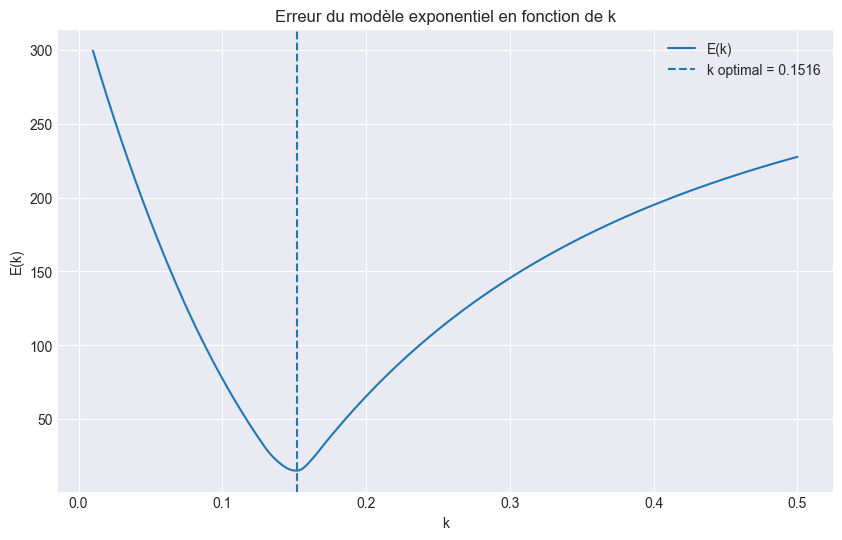

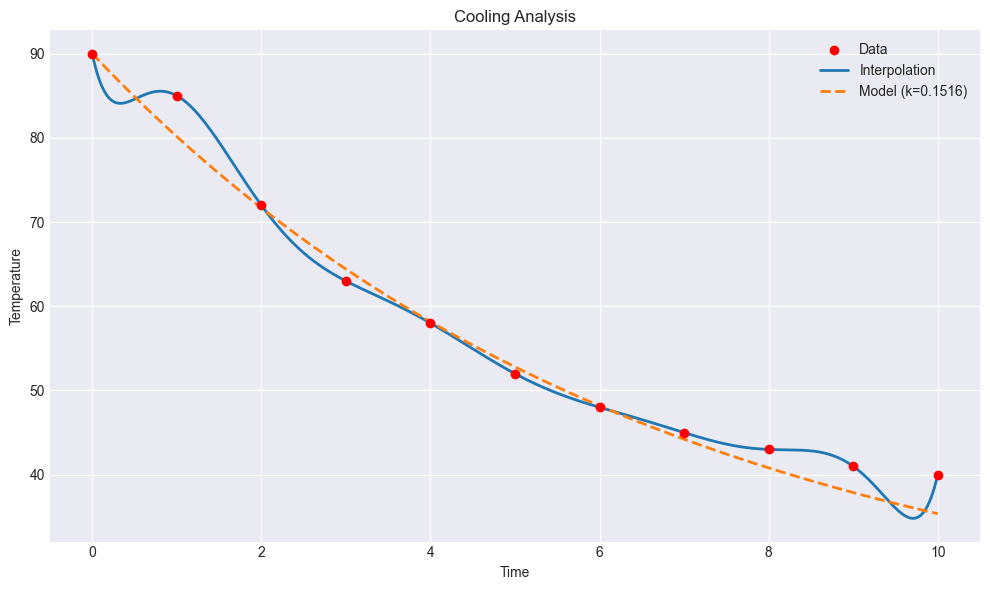

{'T_2.5': 66.34743118286133,
 'T_7.3': 44.11705977510434,
 'heat_loss_rectangle': 18328.87001248491,
 'heat_loss_trapezoidal': 18334.480060965052,
 'heat_loss_simpson': 18330.783789446738,
 'heat_loss_adaptive': 18330.737099834736,
 'k_opt': 0.15163793793967467,
 'max_error_model': 4.8490459118401645,
 'mean_error_model': 1.6770785629111629}

In [6]:

def analyze_cooling_notebook(data: dict) -> dict:
    """Analyse le problème de refroidissement dans le notebook."""
    t_data = data["t"]
    T_data = data["T"]
    T_ambient = data["T_ambient"]
    h_coeff = data["h_coeff"]

    cooling = CoolingProblem(
        t_data=t_data,
        T_data=T_data,
        T_ambient=T_ambient,
        h_coeff=h_coeff,
    )

    t_fine = np.linspace(t_data.min(), t_data.max(), 500)
    T_interp = cooling.temperature(t_fine)

    T_25 = float(cooling.temperature(2.5))
    T_73 = float(cooling.temperature(7.3))

    Q_rect = float(cooling.total_heat_loss(method="rectangle", n=100))
    Q_trap = float(cooling.total_heat_loss(method="trapezoidal", n=100))
    Q_simp = float(cooling.total_heat_loss(method="simpson", n=100))
    Q_adapt = float(cooling.total_heat_loss(method="adaptive", n=100))

    k_opt = float(cooling.estimate_k(k_min=0.01, k_max=0.5, tol=1e-4))
    T_model = cooling.exponential_model(t_fine, k_opt)

    T_model_data = cooling.exponential_model(t_data, k_opt)
    abs_errors = np.abs(T_data - T_model_data)
    max_error = float(np.max(abs_errors))
    mean_error = float(np.mean(abs_errors))

    print(f"T(2.5 s) ≈ {T_25:.4f} °C")
    print(f"T(7.3 s) ≈ {T_73:.4f} °C")
    print(f"Chaleur dissipée (rectangle)   : {Q_rect:.6f} J")
    print(f"Chaleur dissipée (trapèzes)    : {Q_trap:.6f} J")
    print(f"Chaleur dissipée (Simpson)     : {Q_simp:.6f} J")
    print(f"Chaleur dissipée (adaptative)  : {Q_adapt:.6f} J")
    print(f"k optimal ≈ {k_opt:.6f}")
    print(f"Erreur maximale du modèle : {max_error:.6f} °C")
    print(f"Erreur moyenne du modèle  : {mean_error:.6f} °C")

    k_values = np.linspace(0.01, 0.5, 200)
    E_values = [float(cooling.model_error(k)) for k in k_values]

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, E_values, label="E(k)")
    plt.axvline(k_opt, linestyle="--", label=f"k optimal = {k_opt:.4f}")
    plt.xlabel("k")
    plt.ylabel("E(k)")
    plt.title("Erreur du modèle exponentiel en fonction de k")
    plt.legend()
    plt.grid(True)
    plt.show()
    save_current_figure("cooling_error_vs_k.png")
    plt.close()

    visualizer = Visualizer(style="seaborn-v0_8-darkgrid", figsize=(10, 6))
    visualizer.plot_cooling_analysis(t_data, T_data, t_fine, T_interp, k_opt, T_model)
    plt.show()
    save_current_figure("cooling_analysis.png")
    plt.close()

    return {
        "T_2.5": T_25,
        "T_7.3": T_73,
        "heat_loss_rectangle": Q_rect,
        "heat_loss_trapezoidal": Q_trap,
        "heat_loss_simpson": Q_simp,
        "heat_loss_adaptive": Q_adapt,
        "k_opt": k_opt,
        "max_error_model": max_error,
        "mean_error_model": mean_error,
    }


cooling_results = analyze_cooling_notebook(data["cooling"])
cooling_results


## 4. Analyse du problème d'écoulement

C:\Users\karim\AppData\Local\Temp\ipykernel_3736\3257858903.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  results[f"flow_rate_{method}"] = float(
C:\Users\karim\AppData\Local\Temp\ipykernel_3736\3257858903.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  q_local_mid = float(flow.local_flow_rate(3.0))


flow_rate_rectangle : 26.974760
flow_rate_trapezoidal : 26.978408
flow_rate_simpson : 26.976013
flow_rate_adaptive : 26.975974
Débit local à x = 3.0 m   : 5.533842
Accélération à x = 3.0 m  : 0.860575
Travail estimé (m=2.0 kg) : 9.000000


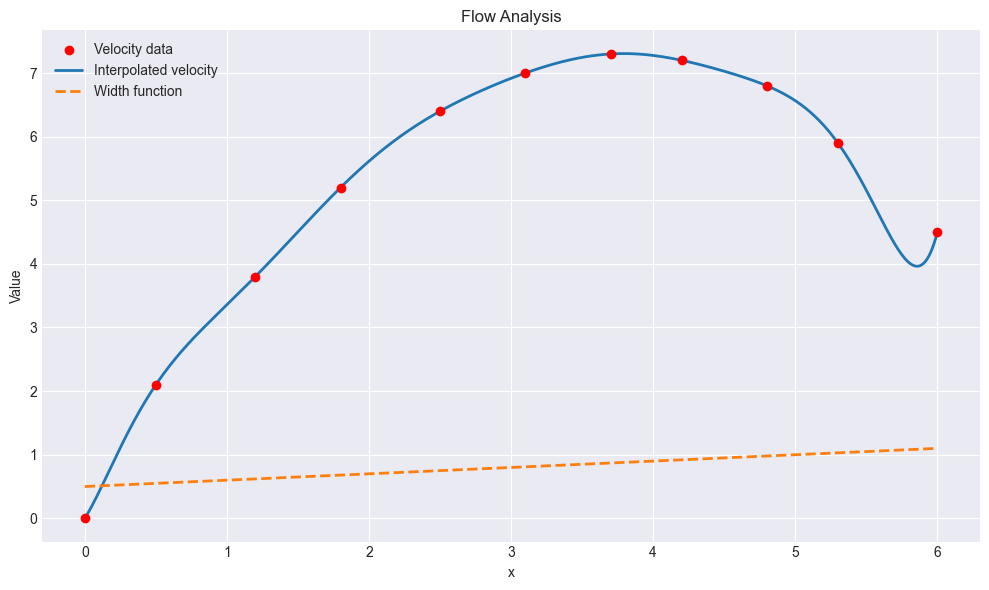

{'flow_rate_rectangle': 26.974759880522612,
 'flow_rate_trapezoidal': 26.97840752237937,
 'flow_rate_simpson': 26.97601260390296,
 'flow_rate_adaptive': 26.975974302688712,
 'local_flow_rate_x_3': 5.533841792980564,
 'acceleration_x_3': 0.8605745054346413,
 'work_mass_2': 9.000000085171266}

In [7]:

def analyze_flow_notebook(data: dict) -> dict:
    """Analyse le problème d'écoulement dans le notebook."""
    x_data = data["x"]
    v_data = data["v"]

    def width_func(x):
        return 0.5 + 0.1 * np.asarray(x)

    flow = FlowProblem(x_data=x_data, v_data=v_data, width_func=width_func)

    x_fine = np.linspace(x_data.min(), x_data.max(), 500)
    v_interp = flow.velocity(x_fine)

    results = {}
    methods_to_try = ["rectangle", "trapezoidal", "simpson", "adaptive"]

    for method in methods_to_try:
        try:
            results[f"flow_rate_{method}"] = float(
                flow.total_flow_rate(method=method, n=100)
            )
        except ValueError:
            print(f"Méthode '{method}' non supportée par FlowProblem, on passe.")

    q_local_mid = float(flow.local_flow_rate(3.0))
    acc_mid = float(flow.acceleration(3.0))
    work_val = float(flow.work(mass=2.0))

    for key, value in results.items():
        print(f"{key} : {value:.6f}")
    print(f"Débit local à x = 3.0 m   : {q_local_mid:.6f}")
    print(f"Accélération à x = 3.0 m  : {acc_mid:.6f}")
    print(f"Travail estimé (m=2.0 kg) : {work_val:.6f}")

    visualizer = Visualizer(style="seaborn-v0_8-darkgrid", figsize=(10, 6))
    visualizer.plot_flow_analysis(x_data, v_data, x_fine, v_interp, width_func)
    plt.show()
    save_current_figure("flow_analysis.png")
    plt.close()

    results["local_flow_rate_x_3"] = q_local_mid
    results["acceleration_x_3"] = acc_mid
    results["work_mass_2"] = work_val

    return results


flow_results = analyze_flow_notebook(data["flow"])
flow_results


## 5. Étude de la convergence des méthodes d'intégration


Méthode : rectangle
n =   2 -> erreur = 1.776911e-02
n =   4 -> erreur = 4.466549e-03
n =   8 -> erreur = 1.118163e-03
n =  16 -> erreur = 2.796364e-04
n =  32 -> erreur = 6.991508e-05
n =  64 -> erreur = 1.747914e-05
n = 128 -> erreur = 4.369809e-06
n = 256 -> erreur = 1.092454e-06

Méthode : trapezoidal
n =   2 -> erreur = 3.564926e-02
n =   4 -> erreur = 8.940076e-03
n =   8 -> erreur = 2.236764e-03
n =  16 -> erreur = 5.593001e-04
n =  32 -> erreur = 1.398319e-04
n =  64 -> erreur = 3.495839e-05
n = 128 -> erreur = 8.739624e-06
n = 256 -> erreur = 2.184908e-06

Méthode : simpson
n =   2 -> erreur = 5.793234e-04
n =   4 -> erreur = 3.701346e-05
n =   8 -> erreur = 2.326241e-06
n =  16 -> erreur = 1.455928e-07
n =  32 -> erreur = 9.102726e-09
n =  64 -> erreur = 5.689702e-10
n = 128 -> erreur = 3.556133e-11
n = 256 -> erreur = 2.222889e-12


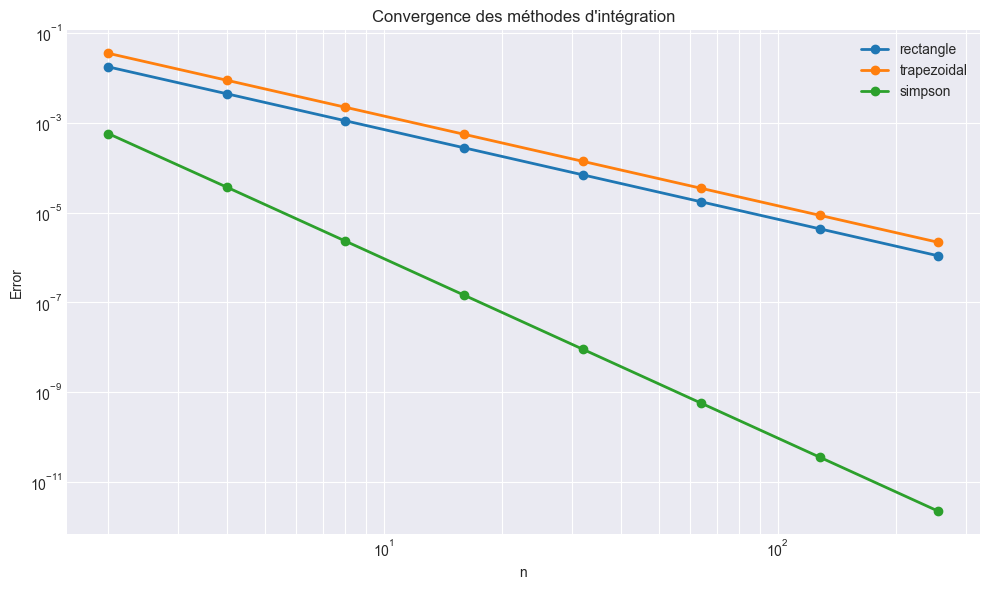

{'n_values': [2, 4, 8, 16, 32, 64, 128, 256],
 'errors': {'rectangle': [0.017769111808837,
   0.0044665486879580385,
   0.001118163463358135,
   0.0002796364063848422,
   6.991507518572249e-05,
   1.747914218164226e-05,
   4.369808882520587e-06,
   1.0924536788525785e-06],
  'trapezoidal': [0.03564926400578017,
   0.008940076098471472,
   0.002236763705256717,
   0.000559300120949402,
   0.00013983185728161374,
   3.495839104861176e-05,
   8.739624432818616e-06,
   2.1849077749269696e-06],
  'simpson': [0.0005793234175477391,
   3.7013462701906974e-05,
   2.3262408519464373e-06,
   1.4559284666759709e-07,
   9.102726350462831e-09,
   5.689702042843692e-10,
   3.5561331657163464e-11,
   2.2228885399044884e-12]},
 'simpson_100_error': 9.545919610332021e-11,
 'adaptive_error': 2.1631296753810147e-10,
 'gauss_legendre_2_error': 0.0003854504515410362,
 'gauss_legendre_3_error': 8.240865232433947e-07}

In [8]:

def integration_error(method_name: str, n: int) -> float:
    """Calcule l'erreur d'intégration pour ∫_0^1 e^x dx."""
    exact = exact_integral_exp_0_1()

    if method_name == "rectangle":
        approx = NewtonCotes.rectangle(test_function, 0.0, 1.0, n=n)
    elif method_name == "trapezoidal":
        approx = NewtonCotes.trapezoidal(test_function, 0.0, 1.0, n=n)
    elif method_name == "simpson":
        if n % 2 != 0:
            n += 1
        approx = NewtonCotes.simpson(test_function, 0.0, 1.0, n=n)
    else:
        raise ValueError(f"Méthode inconnue : {method_name}")

    return abs(float(approx) - exact)


def study_integration_convergence_notebook() -> dict:
    """Étudie la convergence dans le notebook."""
    n_values = np.array([2, 4, 8, 16, 32, 64, 128, 256], dtype=int)
    methods = ["rectangle", "trapezoidal", "simpson"]
    errors = {}

    for method in methods:
        method_errors = []
        print(f"\nMéthode : {method}")
        for n in n_values:
            err = integration_error(method, int(n))
            method_errors.append(err)
            print(f"n = {n:3d} -> erreur = {err:.6e}")
        errors[method] = method_errors

    visualizer = Visualizer(style="seaborn-v0_8-darkgrid", figsize=(10, 6))
    visualizer.plot_convergence(
        n_values=n_values,
        errors=errors,
        methods=methods,
        title="Convergence des méthodes d'intégration",
    )
    plt.show()
    save_current_figure("integration_convergence.png")
    plt.close()

    adaptive = AdaptiveIntegration(tol=1e-6, max_depth=20)
    exact = exact_integral_exp_0_1()

    simpson_100 = NewtonCotes.simpson(test_function, 0.0, 1.0, n=100)
    adapt_val = adaptive.adaptive_simpson(test_function, 0.0, 1.0)

    results = {
        "n_values": n_values.tolist(),
        "errors": {k: [float(v) for v in vals] for k, vals in errors.items()},
        "simpson_100_error": abs(float(simpson_100) - exact),
        "adaptive_error": abs(float(adapt_val) - exact),
    }

    if GaussQuadrature is not None:
        gauss2 = float(GaussQuadrature.gauss_legendre_2(test_function, 0.0, 1.0))
        gauss3 = float(GaussQuadrature.gauss_legendre_3(test_function, 0.0, 1.0))
        results["gauss_legendre_2_error"] = abs(gauss2 - exact)
        results["gauss_legendre_3_error"] = abs(gauss3 - exact)

    return results


convergence_results = study_integration_convergence_notebook()
convergence_results


## 6. Sauvegarde des résultats

In [9]:

all_results = {
    "runge": runge_results,
    "cooling": cooling_results,
    "flow": flow_results,
    "convergence": convergence_results,
}

save_json(all_results, DATA_DIR / "results.json")
print("Résultats sauvegardés dans :", DATA_DIR / "results.json")
all_results


Résultats sauvegardés dans : results\data\results.json


{'runge': {'n_5': {'max_error_equidistant': 0.4326689924794599,
   'max_error_chebyshev': 0.555887387371419},
  'n_10': {'max_error_equidistant': 1.915633147501289,
   'max_error_chebyshev': 0.10915351076845337},
  'n_15': {'max_error_equidistant': 2.1068604877790977,
   'max_error_chebyshev': 0.08309430748091262},
  'n_20': {'max_error_equidistant': 59.76839905928312,
   'max_error_chebyshev': 0.01533338400337414}},
 'cooling': {'T_2.5': 66.34743118286133,
  'T_7.3': 44.11705977510434,
  'heat_loss_rectangle': 18328.87001248491,
  'heat_loss_trapezoidal': 18334.480060965052,
  'heat_loss_simpson': 18330.783789446738,
  'heat_loss_adaptive': 18330.737099834736,
  'k_opt': 0.15163793793967467,
  'max_error_model': 4.8490459118401645,
  'mean_error_model': 1.6770785629111629},
 'flow': {'flow_rate_rectangle': 26.974759880522612,
  'flow_rate_trapezoidal': 26.97840752237937,
  'flow_rate_simpson': 26.97601260390296,
  'flow_rate_adaptive': 26.975974302688712,
  'local_flow_rate_x_3': 5.53

## 7. Résumé final

In [10]:

print("=" * 60)
print("EXÉCUTION TERMINÉE AVEC SUCCÈS")
print("=" * 60)
print(f"Résultats JSON  : {DATA_DIR / 'results.json'}")
print(f"Figures         : {FIGURES_DIR}")


EXÉCUTION TERMINÉE AVEC SUCCÈS
Résultats JSON  : results\data\results.json
Figures         : results\figures
